# Domaća zadaća 2: Faktorizacijski model za preporuku (Recommendation)

**Univerzitet u Zenici**  
**Politehnički fakultet**  
**Odsjek:** Softversko inženjerstvo  
**Predmet:** Rudarenje podataka

**Student:** Delaida Muminović  
**Broj indeksa:** 138

---

Cilj zadaće je implementirati faktorizacijski model za sistem preporuka. Koristi se NMF (Non-negative Matrix Factorization) nad matricom korisnik-film ocjena iz MovieLens dataseta. Prikazuje se originalna rijetka (sparse) matrica, postupak faktorizacije, te rekonstruisana (popunjena) matrica na osnovu koje se generišu preporuke.

## Uvoz potrebnih biblioteka

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import NMF

warnings.filterwarnings("ignore")

## Učitavanje MovieLens dataseta

Koristi se `ratings.csv` iz MovieLens dataseta koji sadrži ocjene korisnika za filmove (skala 0.5-5). Pošto je dataset velik (~100k ocjena), za vizualizaciju uzimamo podskup: 15 najaktivnijih korisnika i 15 najocjenjivanijih filmova.

In [2]:
# Učitavanje podataka
df_ratings = pd.read_csv("ratings.csv")

print(f"Ukupno ocjena: {len(df_ratings)}")
print(f"Broj korisnika: {df_ratings['userId'].nunique()}")
print(f"Broj filmova: {df_ratings['movieId'].nunique()}")
print(f"Raspon ocjena: {df_ratings['rating'].min()} - {df_ratings['rating'].max()}")
print()
display(df_ratings.head(10))

Ukupno ocjena: 100836
Broj korisnika: 610
Broj filmova: 9724
Raspon ocjena: 0.5 - 5.0



,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
5,1,70,3.0,964982400
6,1,101,5.0,964980868
7,1,110,4.0,964982176
8,1,151,5.0,964984041
9,1,157,5.0,964984100


## Kreiranje korisnik-film matrice (podskup)

Od cijelog dataseta biramo 15 najaktivnijih korisnika i 15 najocjenjivanijih filmova. Tako dobijamo matricu koja je dovoljno mala za vizualizaciju, ali koristi stvarne podatke.

In [3]:
# Top 15 najaktivnijih korisnika
top_korisnici = df_ratings["userId"].value_counts().head(15).index.tolist()

# Top 15 najocjenjivanijih filmova
top_filmovi = df_ratings["movieId"].value_counts().head(15).index.tolist()

# Filtriramo dataset na ovaj podskup
df_sub = df_ratings[
    df_ratings["userId"].isin(top_korisnici) & df_ratings["movieId"].isin(top_filmovi)
]

# Pivot tabela: korisnici kao redovi, filmovi kao kolone, ocjene kao vrijednosti
df_ocjene = df_sub.pivot_table(index="userId", columns="movieId", values="rating")

# Popunimo NaN sa 0 (nepoznate ocjene)
ocjene = df_ocjene.fillna(0).values

korisnici = [f"User {uid}" for uid in df_ocjene.index]
filmovi = [f"Film {mid}" for mid in df_ocjene.columns]

print(f"Dimenzije matrice: {df_ocjene.shape} (korisnici x filmovi)")
print(f"Ukupno mogućih ocjena: {df_ocjene.size}")
print(f"Popunjenih ocjena: {df_sub.shape[0]}")
print(f"Praznih (sparse) polja: {df_ocjene.size - df_sub.shape[0]}")
print(f"Gustoća matrice: {np.count_nonzero(ocjene) / df_ocjene.size:.1%}")
print()
display(df_ocjene)

Dimenzije matrice: (15, 15) (korisnici x filmovi)
Ukupno mogućih ocjena: 225
Popunjenih ocjena: 211
Praznih (sparse) polja: 14
Gustoća matrice: 93.8%



movieId,1,50,110,260,296,318,356,480,527,589,593,1196,2571,2858,2959
userId,,,,,,,,,,,,,,,
68,2.5,3.0,2.5,5.0,2.0,3.0,3.5,3.5,4.0,3.5,3.5,5.0,4.5,5.0,2.5
182,4.0,4.5,3.5,3.5,5.0,4.5,5.0,3.5,4.0,2.0,4.5,3.0,5.0,5.0,5.0
249,4.0,4.0,5.0,5.0,4.0,4.5,4.5,4.0,4.5,4.0,4.0,5.0,5.0,4.5,5.0
274,4.0,4.0,4.5,3.0,5.0,4.5,4.5,3.5,4.0,4.5,4.0,4.5,4.0,5.0,5.0
288,4.5,NaN,5.0,5.0,5.0,5.0,5.0,2.0,5.0,4.0,5.0,4.5,3.0,NaN,3.5
307,4.0,4.5,3.5,3.5,4.5,4.5,4.0,3.5,4.5,2.5,4.5,3.0,3.5,4.0,4.0
380,5.0,4.0,4.0,5.0,5.0,3.0,5.0,5.0,NaN,5.0,5.0,5.0,4.5,NaN,4.0
387,NaN,4.5,3.5,4.5,5.0,3.5,4.0,3.0,NaN,3.5,4.0,4.5,4.0,4.5,4.5
414,4.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,4.0,5.0,4.0,5.0,5.0,5.0,5.0


## Vizualizacija rijetke (sparse) matrice

Heatmapa prikazuje originalnu matricu ocjena. Bijela polja su nepoznate ocjene (sparse polja) koje faktorizacijski model treba predvidjeti.

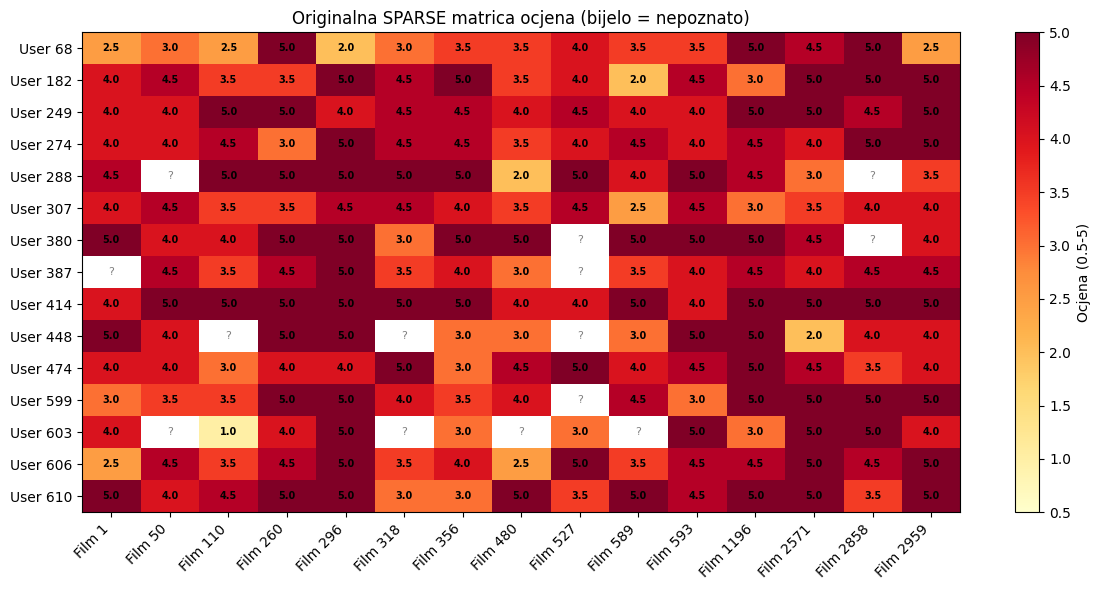

Ukupno '?' polja: 14 od 225 (6%)


In [4]:
# Prikaz sparse matrice - 0 zamjenjujemo sa NaN da bi bijelo bilo "prazno"
sparse_prikaz = ocjene.copy().astype(float)
sparse_prikaz[sparse_prikaz == 0] = np.nan

plt.figure(figsize=(12, 6))
plt.imshow(sparse_prikaz, cmap="YlOrRd", aspect="auto", vmin=0.5, vmax=5)
plt.colorbar(label="Ocjena (0.5-5)")
plt.xticks(range(len(filmovi)), filmovi, rotation=45, ha="right")
plt.yticks(range(len(korisnici)), korisnici)
plt.title("Originalna SPARSE matrica ocjena (bijelo = nepoznato)")

# Označi vrijednosti u ćelijama
for i in range(len(korisnici)):
    for j in range(len(filmovi)):
        if ocjene[i, j] == 0:
            plt.text(j, i, "?", ha="center", va="center", fontsize=8, color="gray")
        else:
            plt.text(j, i, f"{ocjene[i,j]:.1f}", ha="center", va="center", fontsize=7, fontweight="bold")

plt.tight_layout()
plt.show()

n_praznih = np.sum(ocjene == 0)
print(f"Ukupno '?' polja: {n_praznih} od {ocjene.size} ({n_praznih/ocjene.size:.0%})")

## NMF faktorizacija matrice

**NMF (Non-negative Matrix Factorization)** rastavlja matricu ocjena $R$ na dvije manje matrice:

$$R \approx W \times H$$

- $W$ (korisnici x komponente) - profil svakog korisnika
- $H$ (komponente x filmovi) - profil svakog filma
- Broj komponenti (`n_components`) predstavlja broj skrivenih "tema" ili "žanrova"

Množeći $W \times H$ dobijamo rekonstruisanu matricu sa predviđenim ocjenama za sva polja, uključujući ona koja su bila prazna.

In [5]:
# NMF faktorizacija - 5 skrivenih komponenti (latentni žanrovi/teme)
n_komponenti = 5

nmf_model = NMF(n_components=n_komponenti, init="random", random_state=42, max_iter=500)

# W matrica: korisnici x komponente
W = nmf_model.fit_transform(ocjene)

# H matrica: komponente x filmovi
H = nmf_model.components_

print(f"Originalna matrica R: {ocjene.shape}")
print(f"W matrica (korisnici x komponente): {W.shape}")
print(f"H matrica (komponente x filmovi): {H.shape}")
print(f"\nBroj skrivenih komponenti: {n_komponenti}")
print(f"Greška rekonstrukcije: {nmf_model.reconstruction_err_:.4f}")

Originalna matrica R: (15, 15)
W matrica (korisnici x komponente): (15, 5)
H matrica (komponente x filmovi): (5, 15)

Broj skrivenih komponenti: 5
Greška rekonstrukcije: 7.2456


## Prikaz W i H matrica

W matrica pokazuje koliko svaki korisnik pripada svakoj skrivenoj komponenti (žanru). H matrica pokazuje koliko svaki film pripada svakoj komponenti.

In [6]:
komponente = [f"Komp. {i+1}" for i in range(n_komponenti)]

print("W matrica (korisnici x komponente) - prvih 5 korisnika:")
df_W = pd.DataFrame(W, index=korisnici, columns=komponente).round(2)
display(df_W.head())

print("\nH matrica (komponente x filmovi):")
df_H = pd.DataFrame(H, index=komponente, columns=filmovi).round(2)
display(df_H)

W matrica (korisnici x komponente) - prvih 5 korisnika:


,Komp. 1,Komp. 2,Komp. 3,Komp. 4,Komp. 5
User 68,1.70,1.82,0.81,0.38,0.16
User 182,2.15,2.18,0.83,0.00,0.30
User 249,2.91,2.24,0.87,0.46,0.04
User 274,2.70,2.07,0.87,0.35,0.07
User 288,3.61,2.49,0.00,0.72,0.00



H matrica (komponente x filmovi):


,Film 1,Film 50,Film 110,Film 260,Film 296,Film 318,Film 356,Film 480,Film 527,Film 589,Film 593,Film 1196,Film 2571,Film 2858,Film 2959
Komp. 1,0.09,0.00,1.39,1.06,1.34,1.11,1.29,0.32,0.00,0.86,0.85,0.86,0.93,0.00,0.96
Komp. 2,1.31,0.00,0.11,0.09,0.00,0.28,0.12,0.12,2.03,0.00,0.62,0.13,0.13,0.00,0.01
Komp. 3,0.00,4.43,0.23,0.97,0.53,1.14,0.30,2.61,0.00,1.53,0.15,1.72,1.87,4.86,1.88
Komp. 4,1.18,0.93,0.00,0.56,0.27,0.00,0.12,1.03,0.00,0.83,0.53,0.76,0.14,0.00,0.29
Komp. 5,1.40,0.37,0.44,3.30,4.33,0.00,2.55,0.00,0.00,0.00,3.47,2.35,3.28,4.15,3.34


## Rekonstruisana matrica (W x H)

Množeći W i H dobijamo popunjenu matricu. Sada svako polje ima predviđenu ocjenu - uključujući i ona koja su ranije bila prazna.

In [7]:
# Rekonstrukcija: R_pred = W x H
R_pred = np.dot(W, H)

# Ograničimo ocjene na raspon 0.5-5
R_pred = np.clip(R_pred, 0.5, 5)

df_rekonstruisana = pd.DataFrame(R_pred, index=korisnici, columns=filmovi).round(2)

print("Rekonstruisana (popunjena) matrica:")
display(df_rekonstruisana)

Rekonstruisana (popunjena) matrica:


,Film 1,Film 50,Film 110,Film 260,Film 296,Film 318,Film 356,Film 480,Film 527,Film 589,Film 593,Film 1196,Film 2571,Film 2858,Film 2959
User 68,3.22,3.99,2.83,3.51,3.51,3.33,3.13,3.27,3.70,3.02,3.46,3.76,3.92,4.59,3.83
User 182,3.48,3.78,3.56,4.31,4.65,3.95,4.08,3.12,4.42,3.12,4.36,4.28,4.85,5.00,4.68
User 249,3.80,4.28,4.51,4.56,4.68,4.86,4.48,3.95,4.54,4.21,4.39,4.74,4.84,4.40,4.74
User 274,3.46,4.21,4.22,4.33,4.47,4.59,4.23,3.76,4.21,3.95,4.12,4.52,4.70,4.52,4.59
User 288,4.44,0.67,5.00,4.48,5.00,4.72,5.00,2.20,5.00,3.70,4.99,3.98,3.80,0.50,3.72
User 307,3.81,3.71,3.50,3.80,3.87,3.95,3.64,3.30,4.78,3.30,3.96,3.98,4.16,4.15,4.00
User 380,4.89,3.51,3.99,5.00,5.00,3.20,4.38,4.75,0.50,5.00,4.76,5.00,3.52,0.50,4.14
User 387,0.88,3.86,3.70,4.31,4.80,3.65,4.05,3.15,0.50,3.56,3.15,4.24,4.57,4.81,4.71
User 414,3.66,4.90,4.81,4.88,4.97,5.00,4.72,4.44,4.05,4.71,4.43,5.00,5.00,4.79,5.00
User 448,5.00,3.59,0.50,4.81,4.73,0.50,2.66,3.55,0.50,2.86,4.84,4.68,3.41,3.77,3.97


## Vizualizacija: Sparse vs Rekonstruisana matrica

Poređenje originalne (rijetke) matrice i rekonstruisane (popunjene) matrice nakon NMF faktorizacije.

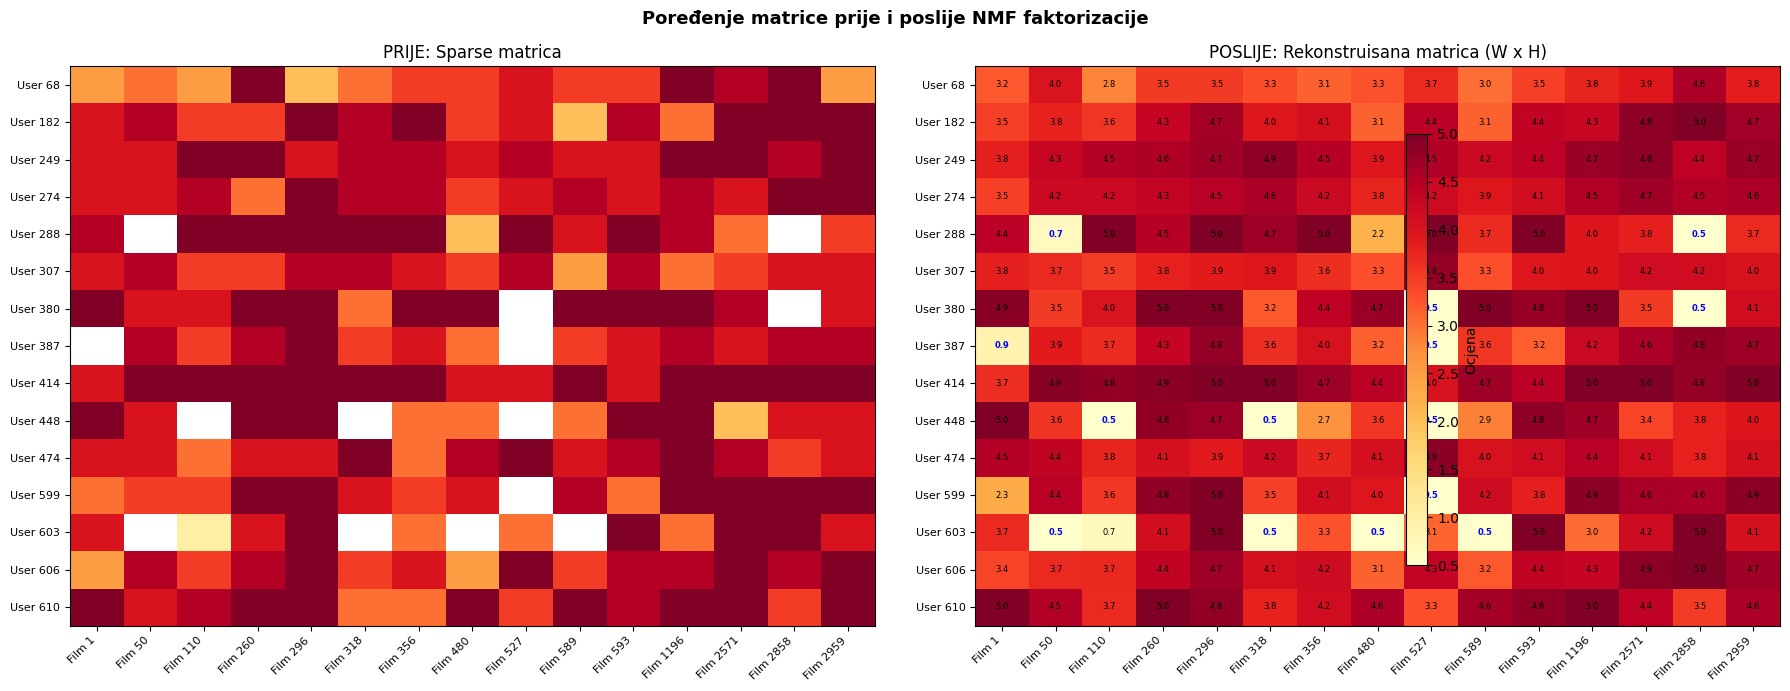

Plavi brojevi = predviđene ocjene za filmove koje korisnik NIJE gledao


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Lijevo: originalna sparse matrica
ax1 = axes[0]
sparse_prikaz = ocjene.copy().astype(float)
sparse_prikaz[sparse_prikaz == 0] = np.nan
im1 = ax1.imshow(sparse_prikaz, cmap="YlOrRd", aspect="auto", vmin=0.5, vmax=5)
ax1.set_xticks(range(len(filmovi)))
ax1.set_xticklabels(filmovi, rotation=45, ha="right", fontsize=8)
ax1.set_yticks(range(len(korisnici)))
ax1.set_yticklabels(korisnici, fontsize=8)
ax1.set_title("PRIJE: Sparse matrica")

# Desno: rekonstruisana matrica
ax2 = axes[1]
im2 = ax2.imshow(R_pred, cmap="YlOrRd", aspect="auto", vmin=0.5, vmax=5)
ax2.set_xticks(range(len(filmovi)))
ax2.set_xticklabels(filmovi, rotation=45, ha="right", fontsize=8)
ax2.set_yticks(range(len(korisnici)))
ax2.set_yticklabels(korisnici, fontsize=8)
ax2.set_title("POSLIJE: Rekonstruisana matrica (W x H)")

# Označi nova predviđanja plavom bojom na desnoj matrici
for i in range(len(korisnici)):
    for j in range(len(filmovi)):
        val = R_pred[i, j]
        if ocjene[i, j] == 0:
            ax2.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=6, color="blue", fontweight="bold")
        else:
            ax2.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=6)

fig.colorbar(im2, ax=axes, label="Ocjena", shrink=0.8)
plt.suptitle("Poređenje matrice prije i poslije NMF faktorizacije", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Plavi brojevi = predviđene ocjene za filmove koje korisnik NIJE gledao")

## Generisanje preporuka

Na osnovu rekonstruisane matrice, za prvih 5 korisnika biramo filmove koje NISU gledali, a za koje model predviđa najvišu ocjenu.

In [9]:
print("=" * 60)
print("PREPORUKE (top 3 negledana filma za prvih 5 korisnika)")
print("=" * 60)

for i in range(min(5, len(korisnici))):
    # Indeksi filmova koje korisnik NIJE gledao
    negledani = np.where(ocjene[i] == 0)[0]

    if len(negledani) == 0:
        print(f"\n{korisnici[i]}: Gledao/la sve filmove iz podskupa!")
        continue

    # Sortiraj po predviđenoj ocjeni (opadajuće)
    predvidjene = [(filmovi[j], R_pred[i, j]) for j in negledani]
    predvidjene.sort(key=lambda x: x[1], reverse=True)

    # Top 3 preporuke
    top3 = predvidjene[:3]
    preporuke = ", ".join([f"{film} ({ocjena:.1f})" for film, ocjena in top3])
    print(f"\n{korisnici[i]}: {preporuke}")

PREPORUKE (top 3 negledana filma za prvih 5 korisnika)

User 68: Gledao/la sve filmove iz podskupa!

User 182: Gledao/la sve filmove iz podskupa!

User 249: Gledao/la sve filmove iz podskupa!

User 274: Gledao/la sve filmove iz podskupa!

User 288: Film 50 (0.7), Film 2858 (0.5)


## Kvalitet rekonstrukcije - poređenje sa originalnim ocjenama

Provjeravamo koliko su predviđene ocjene blizu originalnih (samo za polja koja su bila popunjena).

Metrike kvaliteta (na poznatim ocjenama):
  MAE  (Mean Absolute Error): 0.357
  RMSE (Root Mean Squared Error): 0.482


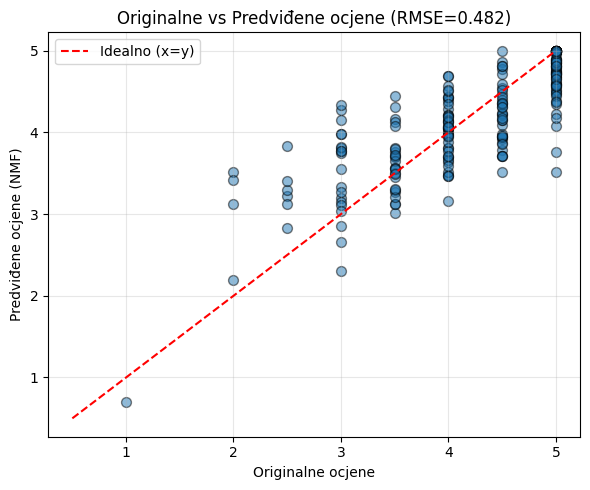

In [10]:
# Poređenje samo na poznatim ocjenama
mask = ocjene > 0
originalne = ocjene[mask]
predvidjene_ocjene = R_pred[mask]

mae = np.mean(np.abs(originalne - predvidjene_ocjene))
rmse = np.sqrt(np.mean((originalne - predvidjene_ocjene) ** 2))

print(f"Metrike kvaliteta (na poznatim ocjenama):")
print(f"  MAE  (Mean Absolute Error): {mae:.3f}")
print(f"  RMSE (Root Mean Squared Error): {rmse:.3f}")

# Scatter plot: originalne vs predviđene
plt.figure(figsize=(6, 5))
plt.scatter(originalne, predvidjene_ocjene, alpha=0.5, edgecolors="black", s=50)
plt.plot([0.5, 5], [0.5, 5], "r--", label="Idealno (x=y)")
plt.xlabel("Originalne ocjene")
plt.ylabel("Predviđene ocjene (NMF)")
plt.title(f"Originalne vs Predviđene ocjene (RMSE={rmse:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Zaključak

- Korišten je **MovieLens dataset** (`ratings.csv`) sa ~100.000 ocjena korisnika za filmove.
- Za vizualizaciju je uzet podskup od 15 najaktivnijih korisnika i 15 najocjenjivanijih filmova.
- Prikazana je **rijetka (sparse) matrica** u kojoj veliki broj polja nije popunjen.
- Primjenjena je **NMF faktorizacija** koja rastavlja matricu $R$ na dvije manje matrice $W$ i $H$ sa 5 skrivenih komponenti.
- Množenjem $W \times H$ dobijena je **rekonstruisana (popunjena) matrica** sa predviđenim ocjenama za sva polja.
- Na osnovu predviđenih ocjena generisane su **preporuke filmova** za korisnike.
- Kvalitet rekonstrukcije mjeren je MAE i RMSE metrikama.